# DiffTRe training for the titanium BCC–liquid transition

In [1]:
from pathlib import Path
import os
import sys

TUTORIAL = Path.cwd().resolve()
TRAINING = TUTORIAL / "training"
OUTPUT = TRAINING / "output"

GPU = "0"
EPOCHS = 45
CHECKPOINT_EVERY = 10

os.environ["CUDA_VISIBLE_DEVICES"] = GPU
os.environ.setdefault("OEQ_NOTORCH", "1")
os.environ.setdefault("NVIDIA_TF32_OVERRIDE", "0")
os.environ.setdefault("JAX_DEFAULT_MATMUL_PRECISION", "highest")
sys.path.insert(0, str(TUTORIAL))

print(f"Tutorial: {TUTORIAL}")
print(f"GPU: {GPU}")

Tutorial: /ds/project/paul/projects/chemAiML26/examples/02_diffttc
GPU: 0


## Data loading

In [2]:
from IPython.display import display
import jax
import jax.numpy as jnp
import optax
from chemtrain import ensemble, quantity, trainers
from chemtrain.compose import mace_jax as mace_jax_compose
from chemtrain.data import preprocessing
from jax_md import partition, simulate, space
from jax_md_mod import custom_quantity
from mace_jax.modules.wrapper_ops import EquivarianceConfig

from difftre_helpers import load_phase_boxes, phase_box_summary, stack_phase_statepoints
from ip_helpers import (
    lammps_atom_count,
    load_observables,
    load_pinning_parameters,
    pinning_free_energy_difference,
)
from units import ANGSTROM_TO_NM as length_scale, EV_TO_KJ_PER_MOL as energy_scale

# Compute the chemical potential between the phases and load the reference boxes

pinning = load_pinning_parameters(TUTORIAL / "input/interface_pinning.toml")

pinning["center"] = pinning["production_center"]
temperature = float(pinning["temperature"])
pressure = float(pinning["pressure_gpa"])
interface_atoms = lammps_atom_count(TUTORIAL / "input/interface_start.lmpdat")
ip = pinning_free_energy_difference(
    pinning,
    load_observables(TUTORIAL / "results/interface.txt"),
    interface_atoms,
)
reference_delta_mu = ip[
    "chemical_potential_difference_kj_per_mol"
]

print(f"Target state: {temperature:.1f} K, {pressure:.3f} GPa")
print("JAX-MD units: nm, kJ/mol, ps, g/mol")
print(
    "Pinning reference Δμ(BCC-liquid): "
    f"{reference_delta_mu:.4f} kJ/mol/atom"
)

phase_boxes = load_phase_boxes(TRAINING)

phase_data = {
    key: jnp.asarray(value)
    for key, value in stack_phase_statepoints(phase_boxes, temperature, pressure).items()
}


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Target state: 1941.0 K, 0.000 GPa
JAX-MD units: nm, kJ/mol, ps, g/mol
Pinning reference Δμ(BCC-liquid): 0.9314 kJ/mol/atom


## Model loading

In [3]:
# Use the OpenEquivariance kernels used for the validated tutorial run.
equivariance = EquivarianceConfig(
    backend="openeq",
    layout="mul_ir",
    group="O3_e3nn",
    optimize_all=False,
    optimize_channelwise=True,
    optimize_fctp=False,
    conv_fusion=True,
)

displacement_fn, shift_fn = space.periodic_general(
    phase_data["box"][0], fractional_coordinates=True
)

# We fine-tune the MH-1 model we benchmarked before
torch_model, model_config = mace_jax_compose.load_foundational_model(
    family="mp", version="mh-1"
)
cutoff = float(model_config["r_max"]) * length_scale
model_variables, mace_apply = mace_jax_compose.mace_jax_neighborlist_from_torch(
    model_config,
    torch_model,
    displacement_fn,
    max_edge_multiplier=None,
    per_particle=False,
    species_mapping=mace_jax_compose.AtomicNumberMapping(max_number=100),
    scale_pos=length_scale,
    scale_pot=energy_scale,
    equivariance_config=equivariance,
    head="matpes_r2scan",
)
# The trainable tree is a correction to this frozen foundation model.
base_params = model_variables["params"]
initial_params = jax.tree.map(jnp.zeros_like, base_params)

def energy_fn_template(params):
    # We add the learned correction here.
    # Other differentiable changes, such as a calibrated energy offset, would fit here too.
    full_params = jax.tree.map(jnp.add, base_params, params)
    variables = {**model_variables, "params": full_params}

    def energy_fn(position, neighbor, **state):
        return mace_apply(
            variables,
            position,
            neighbor,
            species=state["species"],
            box=state["box"],
        )

    return energy_fn

print(f"MACE cutoff: {cutoff:.3f} nm")
print("MACE output: kJ/mol")

Using Materials Project MACE for MACECalculator with /home/ga27pej/.cache/mace/macemh1model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/torch/jit/_serialization.py:176: FutureWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


MACE cutoff: 0.600 nm
MACE output: kJ/mol


## Reference simulation

In [4]:
dt = 0.004
friction = 100.0
t_equil = 1.0
t_total = 6.0
t_sample = 0.1

nbrs_init, capacity = preprocessing.allocate_neighborlist(
    phase_data,
    displacement_fn,
    phase_data["box"][0],
    cutoff,
    box_key="box",
    format=partition.Sparse,
    capacity_multiplier=1.5,
    disable_cell_list=True,
    fractional_coordinates=True,
)
print("Neighbour-list capacity:", capacity)

kT = quantity.kb * temperature
timings = ensemble.sampling.process_printouts(
    time_step=dt, total_time=t_total, t_equilib=t_equil, print_every=t_sample
)
_, simulator_template = ensemble.sampling.initialize_simulator_template(
    simulate.nvt_langevin,
    shift_fn=shift_fn,
    nbrs=nbrs_init,
    init_with_PRNGKey=True,
    extra_simulator_kwargs={"kT": kT, "gamma": friction, "dt": dt},
)

def initialize_reference_state(key, positions, box, mass, species):
    neighbor = nbrs_init.update(positions, box=box)
    init_fn, _ = simulator_template(energy_fn_template(initial_params))
    simulation_state = init_fn(
        key, positions, neighbor=neighbor, mass=mass, box=box, species=species
    )
    return ensemble.sampling.SimulatorState(sim_state=simulation_state, nbrs=neighbor)

key = jax.random.PRNGKey(0)
key, reference_key, trainer_key = jax.random.split(key, 3)
reference_states = jax.tree.map(
    lambda *states: jnp.stack(states),
    *(
        initialize_reference_state(key, positions, box, mass, species)
        for key, positions, box, mass, species in zip(
            jax.random.split(reference_key, phase_data["R"].shape[0]),
            phase_data["R"],
            phase_data["box"],
            phase_data["mass"],
            phase_data["species"],
        )
    ),
)

The dataset has max. 59 neighbors per particle and max. 35592 edges in total.
Neighbour-list capacity: (Array(59, dtype=int32), Array(35592, dtype=int32), Array(50.63849, dtype=float32))
Always recompute the neighbor list!
Always recompute the neighbor list!


## DiffTRe optimization

In [5]:
learning_rate = 3.0e-5
weight_decay = 20.0
pressure_gamma = 1.0e-4
free_energy_gamma = 1.0e-5
rdf_gamma = 0.0 # Only for monitoring
target_delta_mu = 0.0

optimizer = optax.chain(
    optax.scale_by_adam(b1=0.5, b2=0.9, eps=1.0e-8, eps_root=1.0e-16),
    optax.add_decayed_weights(weight_decay),
    optax.scale_by_learning_rate(learning_rate),
)

n_states, n_atoms = phase_data["R"].shape[:2]
rdf_bins = 100
rdf_cut = 0.45 * float(jnp.min(jnp.linalg.norm(phase_data["box"], axis=-1)))
rdf_params = custom_quantity.RDFParams(
    jnp.zeros(rdf_bins), *custom_quantity.rdf_discretization(rdf_cut, nbins=rdf_bins)
)
# DiffTRe learns F(model) - F(reference), so subtract the IP reference Δμ.
# The paired free-energy observable is extensive.
delta_mu = target_delta_mu - reference_delta_mu
delta_f = n_atoms * delta_mu
state_kwargs = {
    "box": phase_data["box"],
    "species": phase_data["species"],
    "kT": jnp.full(n_states, kT),
}
# We compute the RDF here just for monitoring purposes
quantities = {
    "pressure": custom_quantity.init_pressure(energy_fn_template),
    "rdf": custom_quantity.init_rdf(displacement_fn, rdf_params),
}
observables = {
    "pressure": quantity.observables.init_traj_mean_fn("pressure"),
    "free_energy": quantity.observables.init_identity_fn("free_energy"),
    "rdf": quantity.observables.init_traj_mean_fn("rdf"),
}
targets = {
    "pressure": {
        "target": phase_data["pressure"],
        "gamma": jnp.full(n_states, pressure_gamma),
    },
    "rdf": {
        "target": jnp.zeros((n_states, rdf_params.reference.size)),
        "gamma": jnp.full(n_states, rdf_gamma),
    },
    # State 0 is BCC and state 1 liquid, so their offsets have opposite signs.
    "free_energy": {
        "target": jnp.asarray([delta_f, -delta_f]),
        "gamma": jnp.full(n_states, free_energy_gamma),
    },
}
OUTPUT.mkdir(parents=True, exist_ok=True)
trainer = trainers.DifftreParallel(
    trainer_key,
    init_params=initial_params,
    optimizer=optimizer,
    energy_fn_template=energy_fn_template,
    simulator_template=simulator_template,
    neighbor_fn=nbrs_init,
    timings=timings,
    state_kwargs=state_kwargs,
    quantities=quantities,
    targets=targets,
    observables=observables,
    reference_states=reference_states,
    sim_batch_size=n_states,
    reweight_ratio=0.9,
    allowed_reduction=None,
    checkpoint_path=OUTPUT / "checkpoints",
    log_dir=OUTPUT / "training.log",
    parallelism="single",
)

trainer.initialize_trajstates(num_runs=1)

# Record the foundation-model RDF without adding a structural loss.
rdf_reference = trainer.predict(jnp.arange(n_states))["rdf"]
trainer.targets["rdf"]["target"] = rdf_reference

def update_paired_free_energy_target(active_trainer, batch):
    # Before each batch is used in optimization, update the
    # targets in the batch. Therefore, predict the free energy
    # of the corresponding paired statepoint.
    batch = jnp.asarray(batch)
    partner = active_trainer.predict(jnp.mod(batch + 1, 2))
    offsets = jnp.asarray([delta_f, -delta_f])
    active_trainer.targets["free_energy"]["target"] = (
        active_trainer.targets["free_energy"]["target"].at[batch].set(
            partner["free_energy"] + offsets[batch]
        )
    )

# Other registration stages are possible aswell
trainer.add_task("pre_batch", update_paired_free_energy_target)
print(f"BCC-liquid correction target: {delta_f:.2f} kJ/mol for {n_atoms} atoms")

/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/chemtrain/ensemble/reweighting.py:842: UserWarning: Propagation function is not safe by default. Do not forget to use the wrapper around the compute function to ensure that the neighborlist does not overflow.
  warnings.warn(


Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!


/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/jax/_src/numpy/reductions.py:235: UserWarning: Explicitly requested dtype float64 requested in sum is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return _reduction(a, "sum", lax.add, 0, preproc=_cast_to_numeric,
/ds/project/paul/projects/chemAiML26/venv/lib/python3.13/site-packages/jax/_src/numpy/reductions.py:165: UserWarning: Explicitly requested dtype float64 requested in convert_element_type is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax.convert_element_type(result, dtype or result_dtype)


[DifftreParallel] Effective sample sizes (limit: 45.0)
	[Statepoint 0] Effective sample size: 50.00 
	[Statepoint 1] Effective sample size: 50.00 
[DifftreParallel] Start predictions...
	[Statepoint 0]
		kT = 16.138465881347656
	[Statepoint 1]
		kT = 16.138465881347656
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
Always recompute the neighbor list!
BCC-liquid correction target: -638.92 kJ/mol for 686 atoms


## Run training

In [6]:
trainer.train(EPOCHS, checkpoint_freq=CHECKPOINT_EVERY)
trainer.save_trainer(OUTPUT / "trainer.pkl")
print(f"Saved DiffTRe results to {OUTPUT}")

[DifftreParallel] Effective sample sizes (limit: 45.0)
	[Statepoint 1] Effective sample size: 50.00 
	[Statepoint 0] Effective sample size: 50.00 
[DifftreParallel] Start predictions...
	[Statepoint 1]
		kT = 16.138465881347656
	[Statepoint 0]
		kT = 16.138465881347656
[DifftreParallel] Effective sample sizes (limit: 45.0)
	[Statepoint 0] Effective sample size: 50.00 
	[Statepoint 1] Effective sample size: 50.00 
[DifftreParallel] Computing loss...
[DifftreParallel] Computed loss 14.66795825958252 in 0.25 min
[Step Size] Found optimal step size 1.0 with residual None in 0.0 s
[DifftreParallel] Predictions:
	[Statepoint 0]
		entropy = -0.11996334791183472 
		free_energy = -0.0050366525538265705 (target: -638.921875)
		pressure = -457.9123229980469 (target: 0.0)
	[Statepoint 1]
		entropy = 0.43876975774765015 
		free_energy = -0.0012697443598881364 (target: 638.9130859375)
		pressure = -45.08689498901367 (target: 0.0)

[DiffTRe] Epoch 0
	Epoch loss = 14.66796
	Gradient norm: 14684838.0
	

## Evaluate the training run

Saved /ds/project/paul/projects/chemAiML26/examples/02_diffttc/training/output/training_evaluation.svg
[DifftreParallel] Effective sample sizes (limit: 45.0)
	[Statepoint 0] Effective sample size: 48.66 
	[Statepoint 1] Effective sample size: 49.83 
[DifftreParallel] Start predictions...
	[Statepoint 0]
		kT = 16.138465881347656
	[Statepoint 1]
		kT = 16.138465881347656
Saved /ds/project/paul/projects/chemAiML26/examples/02_diffttc/training/output/training_structure.svg


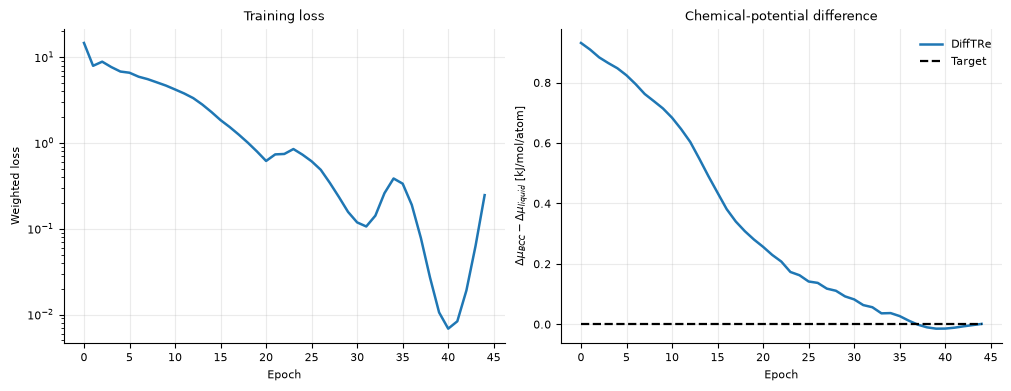

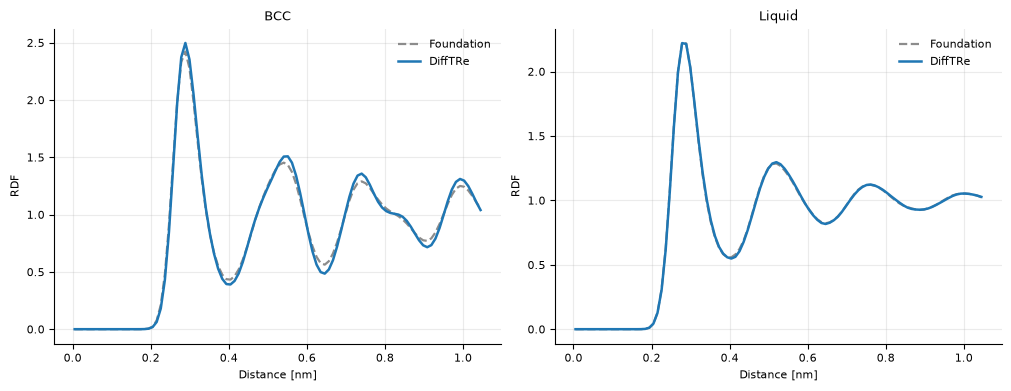

In [7]:
from difftre_helpers import plot_rdf_comparison, plot_training_history, training_history

history = training_history(
    trainer, reference_delta_mu, target_delta_mu, n_atoms
)
training_figure = plot_training_history(history)
training_figure.savefig(OUTPUT / "training_evaluation.svg", bbox_inches="tight")
print("Saved", OUTPUT / "training_evaluation.svg")

rdf_prediction = trainer.predict(jnp.arange(n_states))["rdf"]
rdf_figure = plot_rdf_comparison(
    rdf_params.rdf_bin_centers, rdf_reference, rdf_prediction
)
rdf_figure.savefig(OUTPUT / "training_structure.svg", bbox_inches="tight")
print("Saved", OUTPUT / "training_structure.svg")

## Export the updated model

In [8]:
from difftre_helpers import save_difftre_results

params_path, model_path = save_difftre_results(
    trainer, model_config, torch_model, base_params, equivariance, OUTPUT
)
print("Saved", params_path)
print("Exported", model_path)

Saved /ds/project/paul/projects/chemAiML26/examples/02_diffttc/training/output/final_params.pkl
Exported /ds/project/paul/projects/chemAiML26/examples/02_diffttc/training/output/mace_difftre.ptb
